# Notebook 4 - Lasso and stochastic gradient descent

Project 1, parts g and h.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax import grad
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from Errors import mse
from LASSO import lasso_ista, lasso_subgradient, soft_threshold
from optimisers import sgd, make_batches, step_length
from helper import ols_ridge_gradient, hessian_eigs
from OLS import ols_svd
from Ridge import ridge_closed_form
from sklearn.linear_model import Lasso as SKLasso
np.set_printoptions(precision=4, suppress=True)

x, y = make_data(n=100, noise=0.1, seed=SEED)

## Part g: Lasso via gradient descent

Lasso adds the penalty $\lambda\|\theta\|_1$. It has no closed form, so we solve it with gradient descent. The $\ell_1$ penalty is not differentiable at $\theta_j = 0$, which is what we handle first.

### The subgradient at zero

At $\theta_j = 0$ the absolute value has no single derivative; its subdifferential is the whole interval $[-1, 1]$. We ask `jax.grad` for the derivative of $|\theta|$ at zero.

In [2]:
gabs = grad(lambda t: jnp.abs(t))
print('d|t|/dt at 0 =', float(gabs(0.0)))
print('d|t|/dt at 2 =', float(gabs(2.0)))
print('d|t|/dt at -2 =', float(gabs(-2.0)))

d|t|/dt at 0 = 1.0
d|t|/dt at 2 = 1.0
d|t|/dt at -2 = -1.0


JAX returns 1 at zero. That is a valid subgradient, since 1 lies in the subdifferential $[-1, 1]$, but it is only one choice. Subgradient descent therefore takes a fixed nonzero step at the kink and never sets a coefficient exactly to zero. The cleaner tool is proximal gradient descent, ISTA: take a plain gradient step on the smooth data term, then apply the soft thresholding operator $S_t(z) = \mathrm{sign}(z)\max(|z|-t,0)$, which is the proximal operator of the $\ell_1$ penalty and does drive coefficients to zero.

### Verification against scikit-learn

On degree-10 Runge we set the step from the Hessian, $\gamma = 1/L$ with $L$ the largest eigenvalue, and compare our ISTA solution with scikit-learn Lasso. Note scikit-learn minimises with a $1/(2n)$ data term, so its alpha is our $\lambda/2$.

### Why the ISTA step is $1/L$

The smooth part of the cost, $(1/n)\lVert X\theta - y\rVert^2$, has gradient $(2/n)X^T(X\theta - y)$. This gradient is Lipschitz continuous with constant $L$ equal to the largest eigenvalue of the Hessian $(2/n)X^T X$. Proximal gradient descent converges when the step satisfies $\gamma \le 1/L$, because then the quadratic model that ISTA minimises at each step stays above the true cost, so the step cannot overshoot the minimum. The choice $\gamma = 1/L$ is the largest step that is still safe.

In [3]:
d = 10
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
L = hessian_eigs(Xtr).max()
gamma = 1.0 / L
print(f'L = {L:.3f}, gamma = 1/L = {gamma:.4f}')

for lam in (0.01, 0.05):
    th = lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=200000, tol=1e-12)
    sk = SKLasso(alpha=lam / 2, fit_intercept=False, max_iter=500000, tol=1e-12).fit(Xtr, ytr)
    diff = np.max(np.abs(th - sk.coef_))
    nz = int((np.abs(th) > 1e-8).sum())
    print(f'lambda={lam}: max|ISTA - sklearn| = {diff:.2e}, nonzero {nz}/{d}')

L = 12.787, gamma = 1/L = 0.0782
lambda=0.01: max|ISTA - sklearn| = 1.11e-10, nonzero 3/10
lambda=0.05: max|ISTA - sklearn| = 2.01e-11, nonzero 2/10


In [4]:
# Subgradient vs ISTA: does each reach exact zeros?
th_ista = lasso_ista(Xtr, ytr, 0.05, 1.0 / L)
th_sub  = lasso_subgradient(Xtr, ytr, 0.05, 1.0 / L)
print(f'ISTA        : {int(np.sum(th_ista == 0))} exact zeros of {len(th_ista)}')
print(f'subgradient : {int(np.sum(th_sub == 0))} exact zeros of {len(th_sub)}, smallest |coeff| = {np.min(np.abs(th_sub)):.2e}')

ISTA        : 8 exact zeros of 10
subgradient : 0 exact zeros of 10, smallest |coeff| = 2.45e-04


Our own Lasso matches scikit-learn to about 1e-10, and both leave only a few nonzero coefficients. The implementation is verified.

### Sparsity: Lasso versus Ridge

The point of Lasso is that it sets coefficients exactly to zero, which Ridge never does. We count the nonzero coefficients as a function of the penalty for both methods.

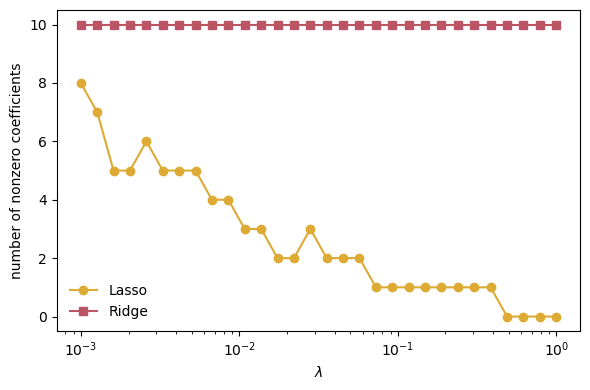

In [5]:
lams = np.logspace(-3, 0, 30)
nz_lasso, nz_ridge = [], []
for lam in lams:
    tl = lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=20000, tol=1e-10)
    tr = ridge_closed_form(Xtr, ytr, lam)
    nz_lasso.append(int((np.abs(tl) > 1e-8).sum()))
    nz_ridge.append(int((np.abs(tr) > 1e-8).sum()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lams, nz_lasso, 'o-', color=YELLOW, label='Lasso')
ax.plot(lams, nz_ridge, 's-', color=RED, label='Ridge')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('number of nonzero coefficients')
ax.legend(frameon=False)
fig.tight_layout()
savefig('g_sparsity', fig)
plt.show()

Lasso removes coefficients one by one as the penalty grows, ending with a sparse model. Ridge keeps all ten, only shrinking them. This is the difference between the $\ell_1$ and $\ell_2$ penalties.

In [6]:
# Runge's function is even, so the odd powers should be the ones Lasso drops
np.set_printoptions(precision=4, suppress=True)
print('OLS coefficients, degree', d, ':', ols_svd(Xtr, ytr))
for lam in (1e-3, 1e-2, 5e-2, 1e-1):
    th = lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=200000, tol=1e-12)
    kept = [k + 1 for k in range(d) if th[k] != 0]
    odd = [k for k in kept if k % 2 == 1]
    print(f'lambda={lam:<6g} nonzero powers {kept}   odd among them {odd}')

OLS coefficients, degree 10 : [ -0.0672  -3.0327  -0.1932  13.664    1.6422 -28.1053  -2.7501  26.6125
   1.3701  -9.405 ]
lambda=0.001  nonzero powers [1, 2, 3, 4, 6, 9, 10]   odd among them [1, 3, 9]
lambda=0.01   nonzero powers [1, 2, 4]   odd among them [1]
lambda=0.05   nonzero powers [2, 10]   odd among them []
lambda=0.1    nonzero powers [2]   odd among them []


best lambda 0.001, test MSE 0.0207


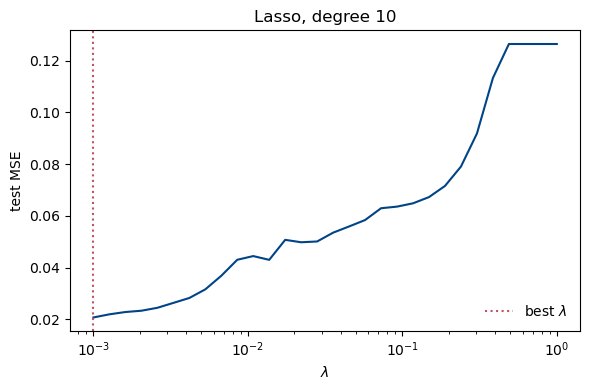

In [7]:
# Test MSE versus lambda for Lasso
mses = [mse(yte, Xte @ lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=20000, tol=1e-10)) for lam in lams]
best = int(np.argmin(mses))
print(f'best lambda {lams[best]:.3g}, test MSE {mses[best]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lams, mses, '-', color=BLUE)
ax.axvline(lams[best], ls=':', color=RED, label='best $\\lambda$')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('test MSE')
ax.set_title(f'Lasso, degree {d}')
ax.legend(frameon=False)
fig.tight_layout()
savefig('g_lasso_mse', fig)
plt.show()

The test error is lowest at a small penalty and rises as too many coefficients are removed. Model selection by cross-validation is done in part i.

## Part h: stochastic gradient descent

We replace the full gradient by a minibatch gradient inside an epoch loop. Every optimiser from part f works with minibatches unchanged. We study the minibatch on the well-conditioned degree-2 Runge problem, where full-batch gradient descent converges cleanly, so the effect of the noise is easy to see. The high-degree, ill-conditioned case is where the adaptive methods of part f and the final model selection of part i take over.

### Minibatch gradient noise

At a fixed point we compute the gradient on many random minibatches and compare their spread with the full gradient. The spread falls as $1/\sqrt{M}$.

In [8]:
d = 2
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
theta_hat = ols_svd(Xtr, ytr)
n_tr = Xtr.shape[0]
theta_fixed = np.zeros(Xtr.shape[1])
g_full = ols_ridge_gradient(theta_fixed, Xtr, ytr, 0.0)
rng = np.random.default_rng(2026)
print('full gradient norm:', round(np.linalg.norm(g_full), 4))
prev = None
for M in (1, 5, 25):
    # drop the remainder batch: 80/25 leaves a batch of 5, which is noisier
    gs = np.array([ols_ridge_gradient(theta_fixed, Xtr[b], ytr[b], 0.0)
                   for _ in range(40)
                   for b in make_batches(n_tr, M, rng)
                   if len(b) == M])
    spread = np.std(gs, axis=0).mean()
    pred = (1.0 / np.sqrt(M)) * np.sqrt((n_tr - M) / (n_tr - 1))
    if prev is None:
        ratio = ''
    else:
        ratio = f'  (drops x{prev / spread:.2f}, finite-population 1/sqrt(M) predicts x{prev_pred / pred:.2f})'
    print(f'M={M:2d}: spread {spread:.3f}{ratio}')
    prev, prev_pred = spread, pred

full gradient norm: 0.437
M= 1: spread 0.518
M= 5: spread 0.226  (drops x2.29, finite-population 1/sqrt(M) predicts x2.29)
M=25: spread 0.081  (drops x2.78, finite-population 1/sqrt(M) predicts x2.61)


The spread falls by a factor 2.29 from M = 1 to M = 5 and 2.78 from M = 5 to M = 25. Sampling without replacement within an epoch gives the finite-population form $(1/\sqrt{M})\sqrt{(n-M)/(n-1)}$, which predicts 2.29 and 2.61 for $n = 80$, so the measurement follows $1/\sqrt{M}$ closely. We exclude the remainder batch: $80/25$ leaves a batch of 5, five times noisier than the others, and including it would mask the scaling. A small batch is noisy but cheap per step.

### SGD versus full batch, and the schedule

We run plain SGD with M = 5 at two constant learning rates and with the schedule $\gamma_t = t_0/(t+t_1)$, and compare with full-batch gradient descent. Distance to the closed-form solution against the number of single-point gradient evaluations.

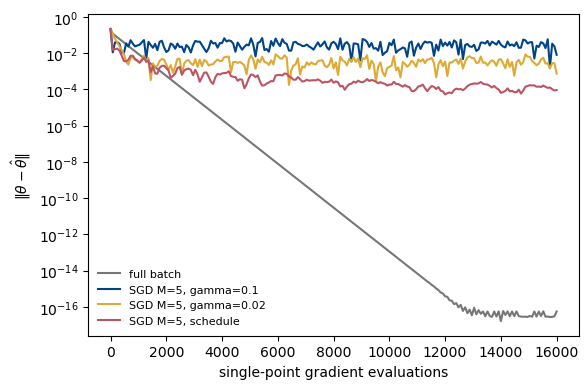

In [9]:
gb = lambda th, Xb, yb: ols_ridge_gradient(th, Xb, yb, 0.0)
n_epochs = 200
evals = np.arange(n_epochs + 1) * n_tr

runs = [
    (dict(batch_size=n_tr, gamma=0.9 * 2 / hessian_eigs(Xtr).max()), GREY, 'full batch'),
    (dict(batch_size=5, gamma=0.1), BLUE, 'SGD M=5, gamma=0.1'),
    (dict(batch_size=5, gamma=0.02), YELLOW, 'SGD M=5, gamma=0.02'),
    (dict(batch_size=5, schedule=(5.0, 50.0)), RED, 'SGD M=5, schedule'),
]
fig, ax = plt.subplots(figsize=(6, 4))
for kw, col, lab in runs:
    hist = sgd(gb, np.zeros(Xtr.shape[1]), Xtr, ytr, method='plain', n_epochs=n_epochs, **kw)
    ax.semilogy(evals, np.linalg.norm(hist - theta_hat, axis=1), color=col, label=lab)
ax.set_xlabel('single-point gradient evaluations')
ax.set_ylabel(r'$\|\theta - \hat\theta\|$')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
savefig('h_sgd_vs_full', fig)
plt.show()

Full-batch gradient descent converges geometrically. SGD at a constant learning rate does not converge; it settles on a plateau whose height scales with the learning rate, because the iterate is a random walk in a cloud of radius set by gamma. The decaying schedule shrinks that cloud and keeps descending.

In [10]:
# Minibatch size study at degree 2, gamma = 0.1, 200 epochs
print('final distance to closed form after 200 epochs, gamma=0.1:')
for M in (1, 5, 20, 100):
    with np.errstate(over='ignore', invalid='ignore'):
        hist = sgd(gb, np.zeros(Xtr.shape[1]), Xtr, ytr, method='plain', n_epochs=200, batch_size=M, gamma=0.1)
    print(f'  M={M:3d}: {np.linalg.norm(hist[-1] - theta_hat):.2e}')

final distance to closed form after 200 epochs, gamma=0.1:
  M=  1: 6.51e-02
  M=  5: 8.14e-03
  M= 20: 3.88e-03
  M=100: 8.47e-16


### Adaptive optimisers in the minibatch loop, epochs, and single-point steps

At a constant learning rate every optimiser plateaus. AdaGrad plateaus lowest because its $1/\sqrt{t}$ decay of the effective step acts as a built-in schedule. More epochs at constant $\gamma$ do not converge: the iterate keeps wandering in the noise cloud. On the ill-conditioned degree-10 problem a single-point step diverges for plain and momentum, while the per-coordinate methods stay bounded.

In [11]:
print(f'degree 2: SGD with different optimisers, M=5, 200 epochs, distance to closed form:')
for method, g in (('plain', 0.1), ('momentum', 0.05), ('adagrad', 0.1), ('rmsprop', 0.01), ('adam', 0.01)):
    with np.errstate(over='ignore', invalid='ignore'):
        hist = sgd(gb, np.zeros(Xtr.shape[1]), Xtr, ytr, method=method, n_epochs=200, batch_size=5, gamma=g)
    print(f'  {method:9s} gamma={g:<5}: {np.linalg.norm(hist[-1] - theta_hat):.2e}')

print('\nDependence on the number of epochs (Adam, M=5, gamma=0.01):')
for E in (10, 50, 200, 500):
    hist = sgd(gb, np.zeros(Xtr.shape[1]), Xtr, ytr, method='adam', n_epochs=E, batch_size=5, gamma=0.01)
    print(f'  {E:4d} epochs: {np.linalg.norm(hist[-1] - theta_hat):.2e}')

print('\nSingle-point steps (M=1) on the ill-conditioned degree-10 problem, 100 epochs, gamma=0.1:')
X10 = polynomial_features(x, 10)
Xtr10, Xte10, ytr10, yte10 = split(X10, y, test_size=0.2, seed=SEED)
Xtr10, Xte10, ytr10, yte10, _ = scale_center(Xtr10, Xte10, ytr10, yte10)
th10 = ols_svd(Xtr10, ytr10)
print(f'  full-Hessian bound 2/lambda_max = {2/hessian_eigs(Xtr10).max():.3f}')
for method in ('plain', 'momentum', 'adagrad', 'rmsprop', 'adam'):
    with np.errstate(over='ignore', invalid='ignore'):
        hist = sgd(gb, np.zeros(Xtr10.shape[1]), Xtr10, ytr10, method=method, n_epochs=100, batch_size=1, gamma=0.1)
    dist = np.linalg.norm(hist[-1] - th10)
    print(f'  {method:9s}: {"DIVERGES" if not np.isfinite(dist) or dist > 1e3 else f"bounded, distance {dist:.2e}"}')

degree 2: SGD with different optimisers, M=5, 200 epochs, distance to closed form:
  plain     gamma=0.1  : 8.14e-03
  momentum  gamma=0.05 : 3.04e-02
  adagrad   gamma=0.1  : 1.47e-04
  rmsprop   gamma=0.01 : 6.03e-04
  adam      gamma=0.01 : 3.49e-03

Dependence on the number of epochs (Adam, M=5, gamma=0.01):
    10 epochs: 5.13e-03
    50 epochs: 9.46e-03
   200 epochs: 3.49e-03
   500 epochs: 9.67e-03

Single-point steps (M=1) on the ill-conditioned degree-10 problem, 100 epochs, gamma=0.1:
  full-Hessian bound 2/lambda_max = 0.156
  plain    : DIVERGES
  momentum : DIVERGES
  adagrad  : bounded, distance 4.23e+01
  rmsprop  : bounded, distance 4.22e+01
  adam     : bounded, distance 4.22e+01


The smaller the batch, the noisier the step and the higher the plateau. From M = 5 to M = 20 the plateau falls by a factor 2.10, close to the $1/\sqrt{M}$ prediction of 2.00. From M = 1 to M = 5 it falls by 7.99, far more than the predicted 2.24, and the reason is instructive: the worst row here has $2\|x_i\|^2 = 20.1$, so a single-point step is stable only for $\gamma < 2/20.1 = 0.099$, and we are running at $\gamma = 0.1$. M = 1 therefore sits on the stability edge rather than in a noise-dominated plateau, and its height is set by near-instability, not by gradient noise. Note also that M = 100 exceeds the training set of 80, so that run is the full batch, which converges to machine precision.

This is the caveat for the ill-conditioned high-degree case, where the same effect is far stronger: a single-point step sees the Hessian of that one point, whose largest eigenvalue is far above the average, so a batch of one can diverge outright at a learning rate that is safe for the full Hessian. That is why part i uses Adam with minibatches, whose per-coordinate step is capped.

## Summary of parts g and h

Lasso needs gradient descent because it has no closed form. Proximal gradient descent with soft thresholding matches scikit-learn and returns exact zeros, which Ridge never does.

Stochastic gradient descent trades an exact gradient for cheap noisy steps. At a constant learning rate it does not converge but settles on a plateau; a larger batch lowers the plateau without removing it, and running longer does not help either. Only a decaying schedule converges. Every optimiser from part f works in the minibatch loop unchanged, and AdaGrad plateaus lowest because its $1/\sqrt{t}$ decay is itself a schedule. On the ill-conditioned degree-10 problem a single-point step diverges for plain descent and momentum at a learning rate that is safe for the full Hessian, which is why part i uses Adam.